## Amazon Sales Prediction

### Problem Statement

The goal is to develop a machine learning model to predict product sales on 
Amazon based on various factors such as product category, price, rating, and 
discount percentage. By analyzing these features, we aim to understand which
factors influence sales and optimize pricing strategies for better revenue 
generation. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv("amazon.csv")

In [ ]:
## About Dataset
##### This dataset is having the data of 1K+ Amazon Product's Ratings and Reviews as per their details listed on the official website of Amazon

### Features

##### product_id - Product ID
#### product_name - Name of the Product
#### category - Category of the Product
#### discounted_price - Discounted Price of the Product
#### actual_price - Actual Price of the Product
#### discount_percentage - Percentage of Discount for the Product
#### rating - Rating of the Product
#### rating_count - Number of people who voted for the Amazon rating
#### about_product - Description about the Product
#### user_id - ID of the user who wrote review for the Product
#### user_name - Name of the user who wrote review for the Product
#### review_id - ID of the user review
#### review_title - Short review
#### review_content - Long review
#### img_link - Image Link of the Product
#### product_link - Official Website Link of the Product

In [3]:
df.size
df.shape

(1465, 16)

In [4]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [6]:
missing_values = df.isnull().sum()
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
# Handeling missing values
df['rating_count'].isnull().sum()
df['rating_count'] = df['rating_count'].astype(str).str.replace(',', '').astype(float)
df['rating_count'].fillna(df['rating_count'].mean(),inplace=True)
df.isnull().sum()

C:\Users\khech\AppData\Local\Temp\ipykernel_4340\230366103.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating_count'].fillna(df['rating_count'].mean(),inplace=True)


product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [8]:
# Remove symbols (₹, %, ,) and convert to numeric
df['discounted_price'] = df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace('[₹,]', '', regex=True).astype(float)
df['discount_percentage'] = df['discount_percentage'].replace('[%,]', '', regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')  # Convert ratings safely


In [9]:
df.dtypes

product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count           float64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object

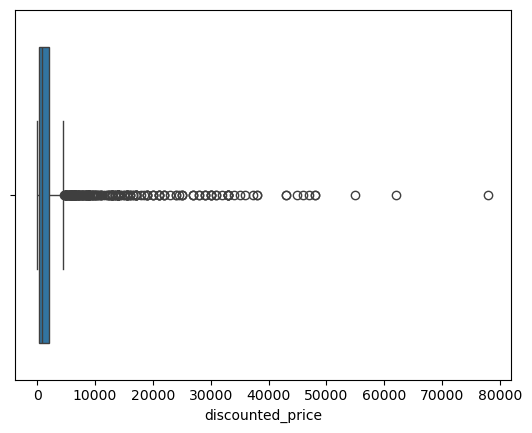

In [10]:
# Boxplot for discounted_price
sns.boxplot(x=df['discounted_price'])
plt.show()

In [11]:

df = df.dropna(subset=['rating'])

# Detect and handle outliers using IQR
Q1 = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating']].quantile(0.25)
Q3 = df[['discounted_price', 'actual_price', 'discount_percentage', 'rating']].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['discounted_price'] = df['discounted_price'].clip(lower_bound['discounted_price'], upper_bound['discounted_price'])
df['actual_price'] = df['actual_price'].clip(lower_bound['actual_price'], upper_bound['actual_price'])
df['rating'] = df['rating'].clip(1, 5)



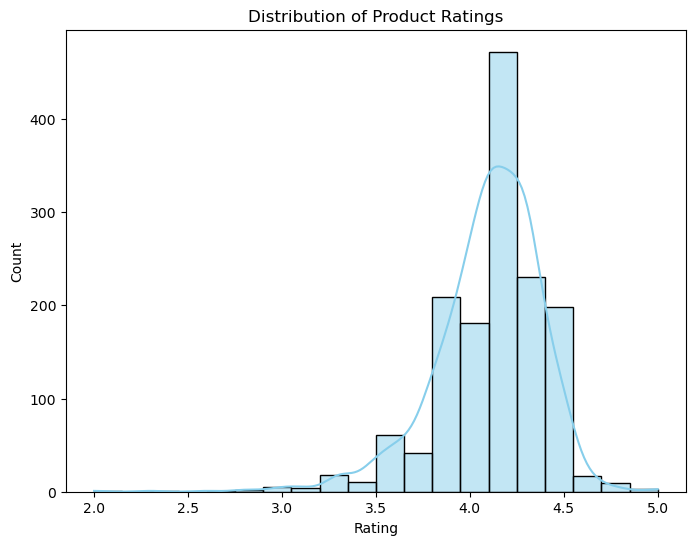

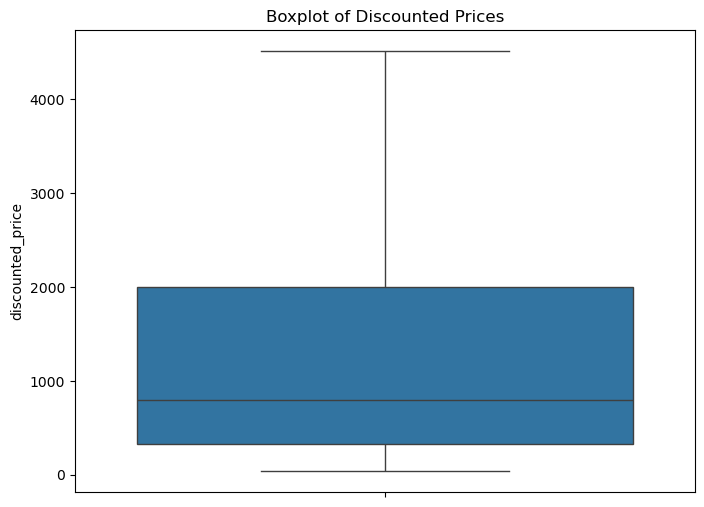

In [27]:

# Exploratory Data Analysis (EDA) Graphs

# 1. Distribution of Ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 2. Boxplot of Discounted Price to Check Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['discounted_price'])
plt.title("Boxplot of Discounted Prices")
plt.show()


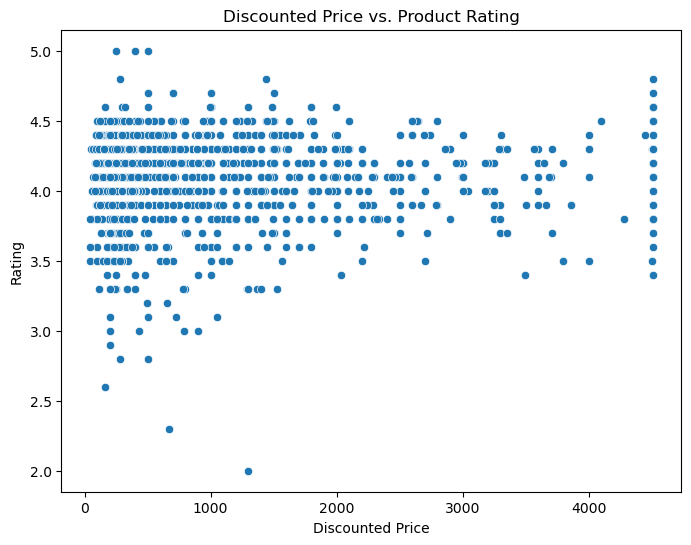

In [28]:

# 3. Scatter Plot of Discounted Price vs. Rating
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['discounted_price'], y=df['rating'])
plt.title("Discounted Price vs. Product Rating")
plt.xlabel("Discounted Price")
plt.ylabel("Rating")
plt.show()


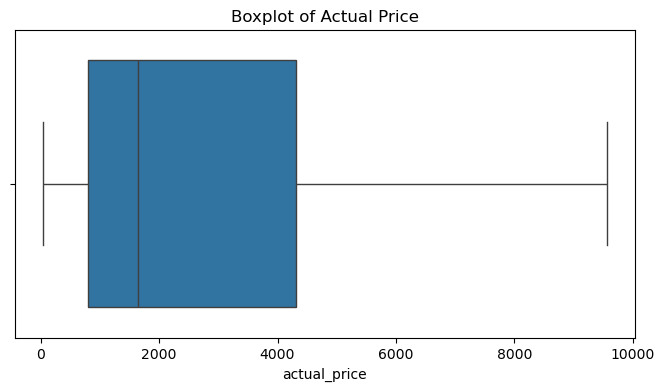

In [29]:
# 4. Boxplot for Actual Price (to check outliers)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['actual_price'])
plt.title("Boxplot of Actual Price")
plt.show()

In [30]:
drop_cols = ['about_product','product_id', 'user_id', 'user_name', 'review_id','product_name', 'review_title', 'review_content', 'img_link', 'product_link']
df = df.drop(columns=drop_cols, errors='ignore')


In [33]:

# Feature Engineering
df['price_discount_ratio'] = df['discounted_price'] / df['actual_price']
df['log_actual_price'] = np.log1p(df['actual_price'])
df['log_discounted_price'] = np.log1p(df['discounted_price'])
df = pd.get_dummies(df, columns=['category'], drop_first=True)


In [36]:

# Splitting data into training & testing sets
X = df.drop(columns=['rating'])
y = df['rating']

# Handle missing values in features
X = X.dropna()
y = y.loc[X.index]


In [39]:
# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [41]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# Handle any remaining NaN values in X_train and X_test
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [45]:


print(X_train.isnull().sum())


discounted_price                                                                                                                   0
actual_price                                                                                                                       0
discount_percentage                                                                                                                0
rating_count                                                                                                                       0
price_discount_ratio                                                                                                               0
                                                                                                                                  ..
category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens        0
category_OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pen

In [47]:
# Train models
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [48]:

# Fill missing values with median in both train and test sets
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  # Use train median to avoid data leakage
print(f"X_train shape: {X_train.shape}")  
print(f"y_train shape: {y_train.shape}")  

X_train shape: (1171, 217)
y_train shape: (1171,)


In [49]:
# Model evaluation
def evaluate_model(y_true, y_pred, model_name):
    print(f"Model: {model_name}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_true, y_pred):.4f}")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print("-"*50)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Model: Linear Regression
Mean Absolute Error (MAE): 0.1751
Mean Squared Error (MSE): 0.0547
R² Score: 0.2947
--------------------------------------------------
Model: Random Forest
Mean Absolute Error (MAE): 0.1695
Mean Squared Error (MSE): 0.0652
R² Score: 0.1594
--------------------------------------------------
